# Import

In [140]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
import warnings

# if you edit the function you need to run these lines again otherwise it won't be updated in this notebook
import importlib, plotting_functions
importlib.reload(plotting_functions) 
from plotting_functions import plot_opinions, plot_opinion_change, plot_opinions_grid, plot_methods

# Functions

## Updating Functions

In [141]:
#updating functions
def one_step(index, agent, agents, advertisers, R):
    
    if advertisers is None:
        total = agents
    else:
        total = np.concatenate((agents, advertisers))

    selected = np.where(np.abs(total - agent) <= R)[0]
    update = np.average(total[selected])
    
    return update

def poll_step(index, agent, agents, advertisers, R):

    if advertisers is None:
        total = np.round(np.delete(agents, index), 1)
    else:
        total = np.concatenate((np.round(np.delete(agents, index), 1), advertisers)) #agents and advertisers with current agent removed
        
    selected = np.where(np.abs(total - agent) <= R)[0]
    update = np.average(np.append(total[selected], agent))

    return update


# rounding func for moderate polling
def round_toward_half(x):
    out = np.empty_like(x)

    # below 0.5 → round up to nearest 0.1
    mask_low = x < 0.5
    out[mask_low] = np.ceil(x[mask_low] * 10) / 10

    # above 0.5 → round down to nearest 0.1
    mask_high = x > 0.5
    out[mask_high] = np.floor(x[mask_high] * 10) / 10

    # equal to 0.5 stays 0.5
    out[x == 0.5] = 0.5

    return out


def moderate_poll_step(index, agent, agents, advertisers, R):

    if advertisers is None:
        total = round_toward_half(np.delete(agents, index))
    else:
        total = np.concatenate((round_toward_half(np.delete(agents, index)), advertisers)) #agents and advertisers with current agent removed
        
    selected = np.where(np.abs(total - agent) <= R)[0]
    update = np.average(np.append(total[selected], agent))

    return update


## Advertising Functions

In [142]:
#advertising strategies
def constant_advertising(agents, advertisers, target, round=None, state=None, k=None):
    return advertisers, state


def stepwise_advertising(agents, advertisers, target, round, delta=0.05, state=None, k=None):
    if round % 5 == 0:
        advertisers = np.minimum(advertisers + delta, 1)
    else:
        advertisers = advertisers

    return advertisers, state

def stepwise_repeating(agents, advertisers, target, round, delta=0.05, state=None, k=None):
    if round % 5 == 0:
        advertisers = (advertisers + delta) % 1
    else:
        advertisers = advertisers

    return advertisers, state


from sklearn.cluster import DBSCAN
import numpy as np

def targeted_clusters2(agents, eps=0.1, min_samples=100):
    agents_arr = np.array(agents).reshape(-1, 1)

    # run DBSCAN
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(agents_arr)
    labels = db.labels_

    # ignore noise points (-1)
    cluster_centers = [agents_arr[labels == i].mean() for i in set(labels) if i != -1]

    # return sorted centers
    return np.sort(cluster_centers)


def targeted_clusters(agents, k=4):
    agents_arr = np.array(agents).reshape(-1, 1)

    #supress warning that not enough clusters are found
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  
        kmeans = KMeans(n_clusters=k, n_init='auto').fit(agents_arr)
        
    centers = np.sort(kmeans.cluster_centers_.flatten())
    return centers


def cluster_guided_advertising(agents, advertisers, target, round=None, state=None, alpha = 0.07, k=None):
    
    m = len(advertisers)

    # compute cluster centers
    centers = targeted_clusters(agents, k)  
    k = len(centers)

    # initialize new advertisers array
    new_advertisers = np.zeros(m)

    # size of each block
    block = m // k

    for i, center in enumerate(centers):
        start = i * block
        end = (i + 1) * block if i < k - 1 else m  # last block takes the rest

        # amount of advertisers in this block
        size = end - start

        # assign based on center vs target
        if center < target:
            new_advertisers[start:end] = np.ones(size)*min(center + alpha, 1)
            # print(center, min(center + delta, 1))
        elif center > target:
            new_advertisers[start:end] = np.ones(size)*max(center - alpha, 0)
            # print(center, min(center + delta, 1))
        else:
            new_advertisers[start:end] = advertisers[start:end]

    return new_advertisers, state


## Model Function

In [33]:

def opinion_model(agents, R, rounds, advertisers=None, advert_strat=constant_advertising, update_func = one_step, target=1, k=None):

    #number of agents
    n = len(agents)
    

    #initialize array to store opinions over time
    agents_history = np.zeros((rounds + 1, n))
    agents_history[0, :] = agents

    if advertisers is not None:
        m = len(advertisers)
        advertisers_history = np.zeros((rounds + 1, m))
        advertisers_history[0, :] = advertisers
    else:
        advertisers_history = None

    #for one of the advertiser strat must initialize state :/
    state = None

    #do t time steps (main loop)
    for r in range(rounds):

        #make a temp list of agents
        agents_next = np.zeros(n)

        # update advertisers
        if advertisers is not None:
            advertisers, state = advert_strat(agents, advertisers, target, round = r, state = state, k=k)

            # advertisers = np.copy(advertisers_next)
            advertisers_history[r + 1, :] = advertisers
            
        else:
            pass

        #loop over all agents
        for i, a in enumerate(agents):
            agents_next[i] = update_func(i, a, agents, advertisers, R)

        #update the agents list
        agents = np.copy(agents_next)
        agents_history[r + 1, :] = agents

        

    return agents, agents_history, advertisers, advertisers_history
 

# Set up

In [34]:
#set seed for reproducibility
np.random.seed(432) 

# set initial opinions & advertisers
n = 1000 #number of agents
agents = np.random.uniform(0, 1, n)

m = 100 #number of advertisers

In [92]:
R = 0.1
rounds = 250

# Continuous

## No advertising

In [36]:
_, agents_history_1, _, advertisers_history_1 = opinion_model(agents = agents, 
                                                                                 R = R, rounds = rounds, 
                                                                                 advertisers = None, 
                                                                                 advert_strat = None, 
                                                                                 update_func = one_step)

No advertisers


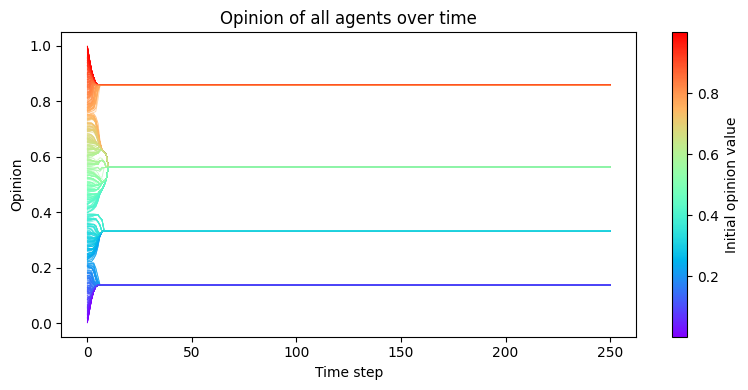

In [37]:
plot_opinions(agents_history_1, agents_history_1[0, :], rounds = rounds, alpha=0.6)

## Stepwise Advertising

In [111]:
# advertisers = np.linspace(0, 0.2, m)
advertisers = np.ones(m)*0.1


In [114]:
_, agents_history_3, _, advertisers_history_3 = opinion_model(agents = agents, 
                                                                                 R = R, rounds = rounds, 
                                                                                 advertisers = advertisers, 
                                                                                 advert_strat = stepwise_advertising, 
                                                                                 update_func = one_step)

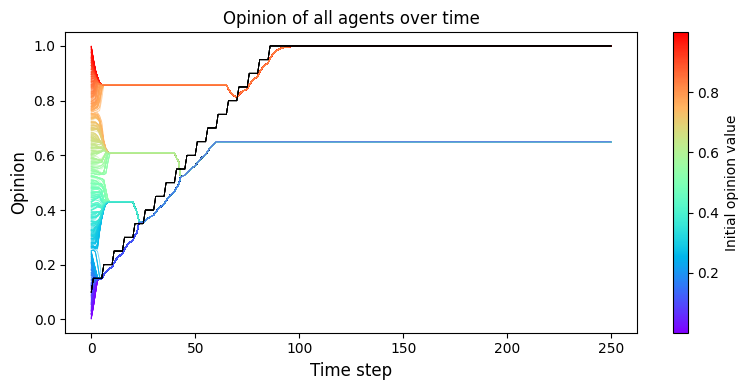

In [115]:
plot_opinions(agents_history_3, agents_history_3[0, :], advertisers_history_3, advertisers_history_3[0, :], rounds = rounds, alpha=0.6)

## Cluster-Guided

In [116]:
advertisers = np.ones(m)*0.1

In [117]:
_, agents_history_4, _, advertisers_history_4 = opinion_model(agents = agents, 
                                                                                 R = R, rounds = rounds, 
                                                                                 advertisers = advertisers, 
                                                                                 advert_strat = cluster_guided_advertising, 
                                                                                 update_func = one_step, k=4)

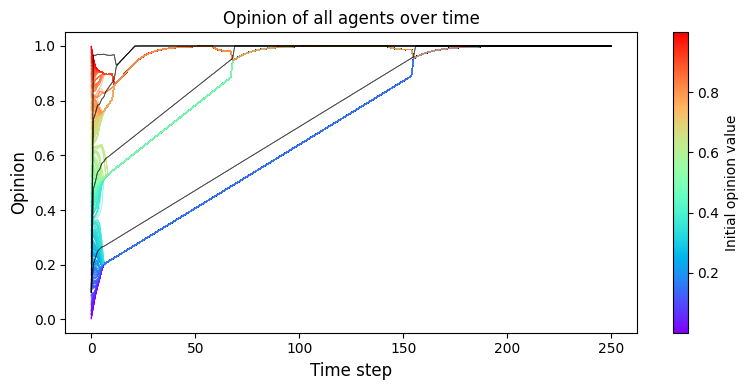

In [118]:
plot_opinions(agents_history_4, agents_history_4[0, :], advertisers_history_4, advertisers_history_4[0, :], rounds = rounds, alpha=0.6)

## Plotting

colour #E69F00 was used
colour #56B4E9 was used
colour #009E73 was used


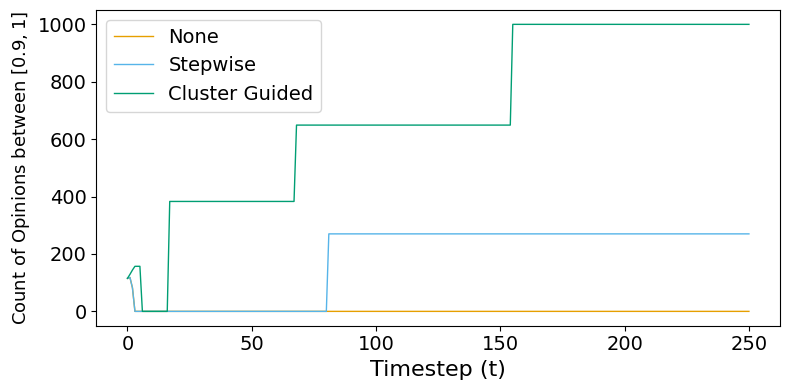

In [ ]:
importlib.reload(plotting_functions) 
from plotting_functions import plot_methods

fig, ax = plt.subplots(figsize=(8,4))

# Color-blind friendly palette
colours = ["#E69F00", "#56B4E9", "#009E73", "#F0E442"]

datasets = [
    (agents_history_1, agents_history_1[0, :], None, None, 'None'),
    (agents_history_3, agents_history_3[0, :], advertisers_history_3, advertisers_history_3[0, :], 'Stepwise'),
    (agents_history_4, agents_history_4[0, :], advertisers_history_4, advertisers_history_4[0, :], 'Cluster Guided'),
]


for i, (a_hist, a_init, adv_hist, adv_init, method) in enumerate(datasets):
    plot_methods(
        a_hist,
        ax=ax,
        colour=colours[i],
        method=method,
        tolerance=0.1,
        linewidth=1
    )

ax.set_xlabel("Timestep (t)", fontsize=16)
ax.set_ylabel(rf"Opinion  between $[0.9, 1]$", fontsize=13)

ax.tick_params(axis='both', labelsize=14)


# Legend size
ax.legend(fontsize=14, title_fontsize=15)

plt.tight_layout()
plt.show()


# Discrete

In [128]:
#set seed for reproducibility
np.random.seed(432) 

# set initial opinions & advertisers
n = 1000 #number of agents
agents = np.random.uniform(0, 1, n)

m = 100 #number of advertisers
rounds = 150

## None

In [129]:
_, agents_history_6, _, advertisers_history_6 = opinion_model(agents = agents, 
                                                                                 R = 0.1, rounds = rounds, 
                                                                                 advertisers = None, 
                                                                                 advert_strat = None, 
                                                                                 update_func = moderate_poll_step)

No advertisers


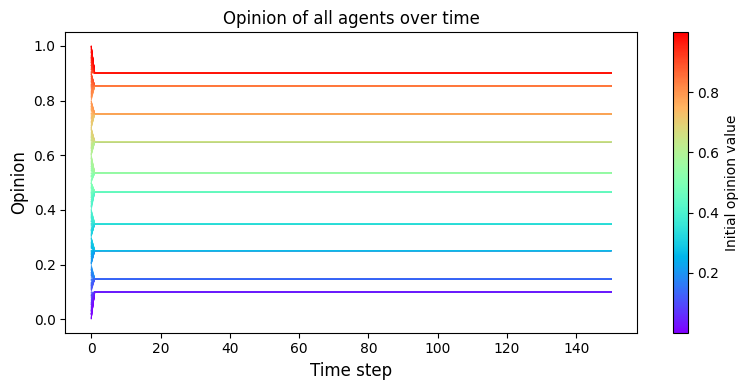

In [130]:
plot_opinions(agents_history_6, agents_history_6[0, :], rounds = rounds, alpha=0.6)

## Cluster Guided

In [131]:
advertisers = np.ones(m)*0.1

In [132]:
_, agents_history_7, _, advertisers_history_7 = opinion_model(agents = agents, 
                                                                                 R = R, rounds = rounds, 
                                                                                 advertisers = advertisers, 
                                                                                 advert_strat = cluster_guided_advertising, 
                                                                                 update_func = moderate_poll_step, k=8)

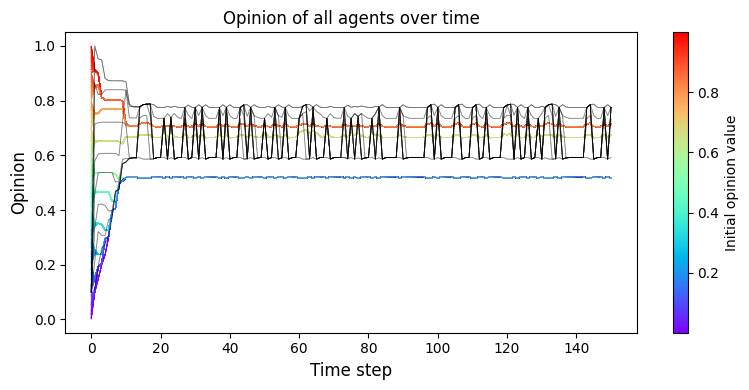

In [133]:
plot_opinions(agents_history_7, agents_history_7[0, :], advertisers_history_7, advertisers_history_7[0, :], rounds = rounds, alpha=0.6)

## Stepwise

In [134]:
# advertisers = np.linspace(0, 0.2, m)
m=100
advertisers = np.ones(m)*0.1

In [135]:
_, agents_history_8, _, advertisers_history_8 = opinion_model(agents = agents, 
                                                                                 R = R, rounds = rounds, 
                                                                                 advertisers = advertisers, 
                                                                                 advert_strat = stepwise_advertising, 
                                                                                 update_func = moderate_poll_step)

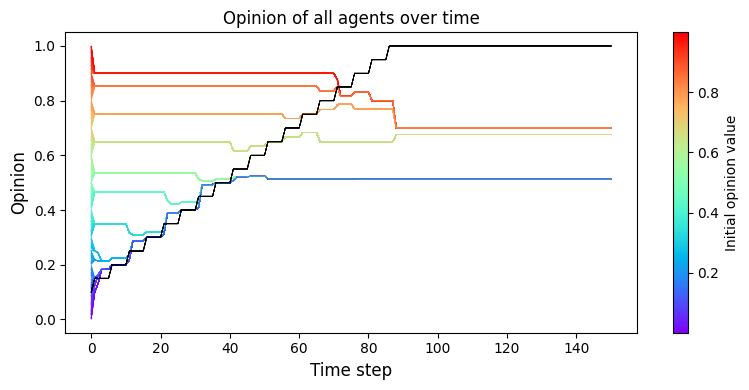

In [136]:
plot_opinions(agents_history_8, agents_history_8[0, :], advertisers_history_8, advertisers_history_8[0, :], rounds = rounds, alpha=0.6)

No advertisers


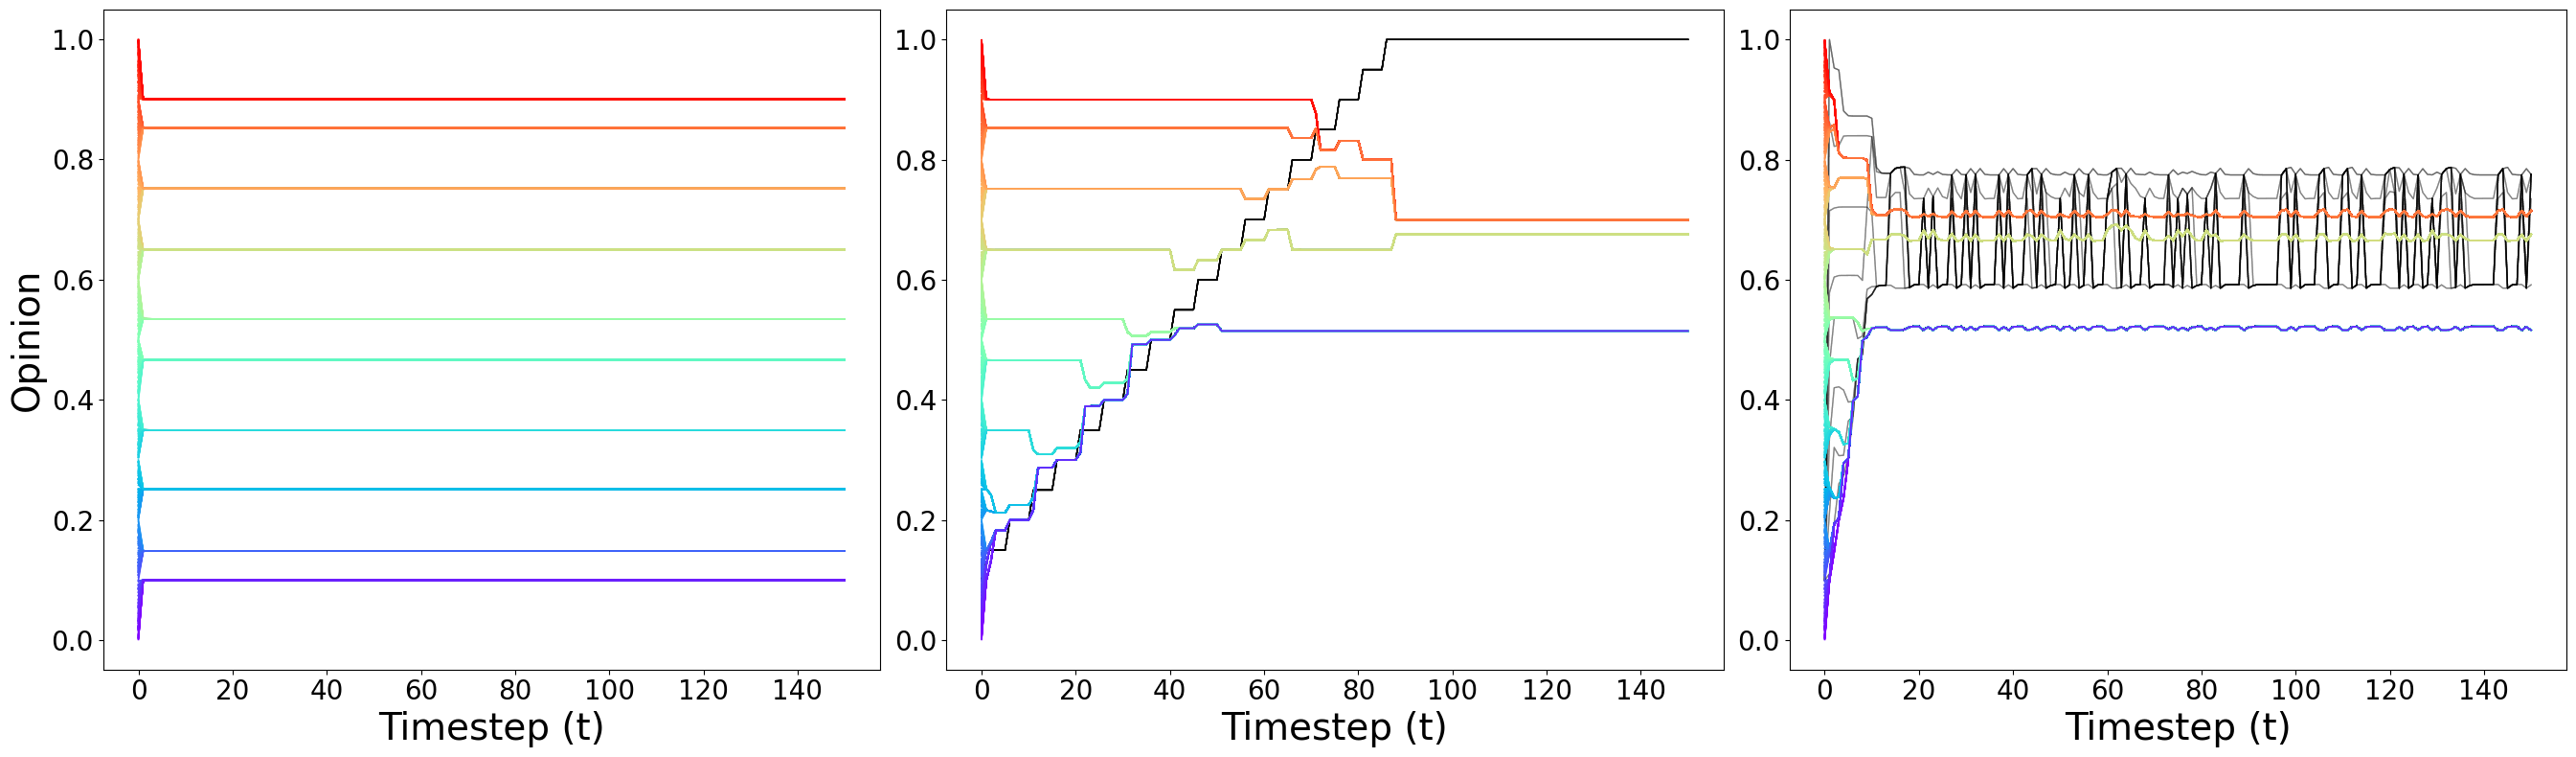

In [139]:
fig, axes = plt.subplots(1, 3, figsize=(27, 8))


datasets = [
    (agents_history_6, agents_history_6[0, :], None, None, 'None'),
    (agents_history_8, agents_history_8[0, :], advertisers_history_8, advertisers_history_8[0, :], 'Stepwise'),
    (agents_history_7, agents_history_7[0, :], advertisers_history_7, advertisers_history_7[0, :], 'Cluster Guided'),
]

a =1 

for ax, (a_hist, a_init, adv_hist, adv_init, method) in zip(axes.flatten(), datasets):
    colors = plt.cm.rainbow(a_init)

    if a ==3:
        light = 0.01
    else:
        light = 0.05

    if adv_hist is not None:
        for i in range(len(adv_init)):
            ax.plot(range(rounds+1), adv_hist[:, i], color="black", alpha=light, linewidth=1)
    else:
        print('No advertisers')

    for i in range(len(a_init)):
        ax.plot(range(rounds+1), a_hist[:, i], color=colors[i], alpha=1, linewidth=1.2)



    ax.tick_params(axis='both', labelsize=20)   # Change only tick label size

    ax.set_xlabel("Timestep (t)", fontsize=28)

    if a == 1:
        ax.set_ylabel("Opinion", fontsize=28)
        a = a + 1
    elif a==3:
       
        sm = plt.cm.ScalarMappable(cmap=plt.cm.rainbow)
        sm.set_array(a_init)
        cbar = plt.colorbar(sm, ax=ax)
        cbar.set_label("Initial opinion value") 
    else:
        pass
        


plt.tight_layout()
plt.show()
